In [1]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)

#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray93"),
    legend.box = "vertical",
    legend.direction = "vertical",
    legend.key.height = unit(0.1,"snpc"),
    legend.key.width  = unit(0.1,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 24),
    axis.text.x  = element_text(size = 20),
    axis.text.y = element_text(size = 20),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 20),
    plot.title = element_text(size = 24)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")


Attaching package: ‘IRdisplay’


The following object is masked from ‘package:xtable’:

    display




# Teorema del Límite Central

Este es uno de los teoremas más importantes en teoría de probabilidad.

 + Como toda la teoría, al principio no quiere decir mucho.
 
 + Al final, es un buen lente desde donde mirar las cosas.
 
 Lo vamos a enunciar, depués vemos cómo lo estuvimos usando todo el tiempo.

## Recordando:

+ Las medidas en general, tienen ruidos, y si medimos varias veces la misma cantidad (salvo cosas gruesas), tenemos una colección de valores.

+ Los ruidos los modelamos con la idea de azar (*azahar*), por lo que debemos corroborar de qué distribución salen los ruidos (acá sólo vimos dist. normales)

   + Nos deshacemos de los ruidos usando la **media muestral** $\overline{x}$
   
   + La media muestral es una ***aproximación*** de la media teórica, $\mu$ 


# Una cuestión de tamaño de muestra

Medimos el acelerómetro del teléfono en reposo $N = 5$ veces. Luego hacemos la misma medida $N = 1000$.

Consideremos la media muestral.

In [104]:
a5 <- rnorm(mean = 9.8, sd = 0.2, n = 5); a100 <- rnorm(mean = 9.8, sd = 0.2, n = 1000);

Warning message in if (freq) x$counts else x$density:
“la condición tiene longitud > 1 y sólo el primer elemento será usado”
Warning message in if (!freq) "Density" else "Frequency":
“la condición tiene longitud > 1 y sólo el primer elemento será usado”


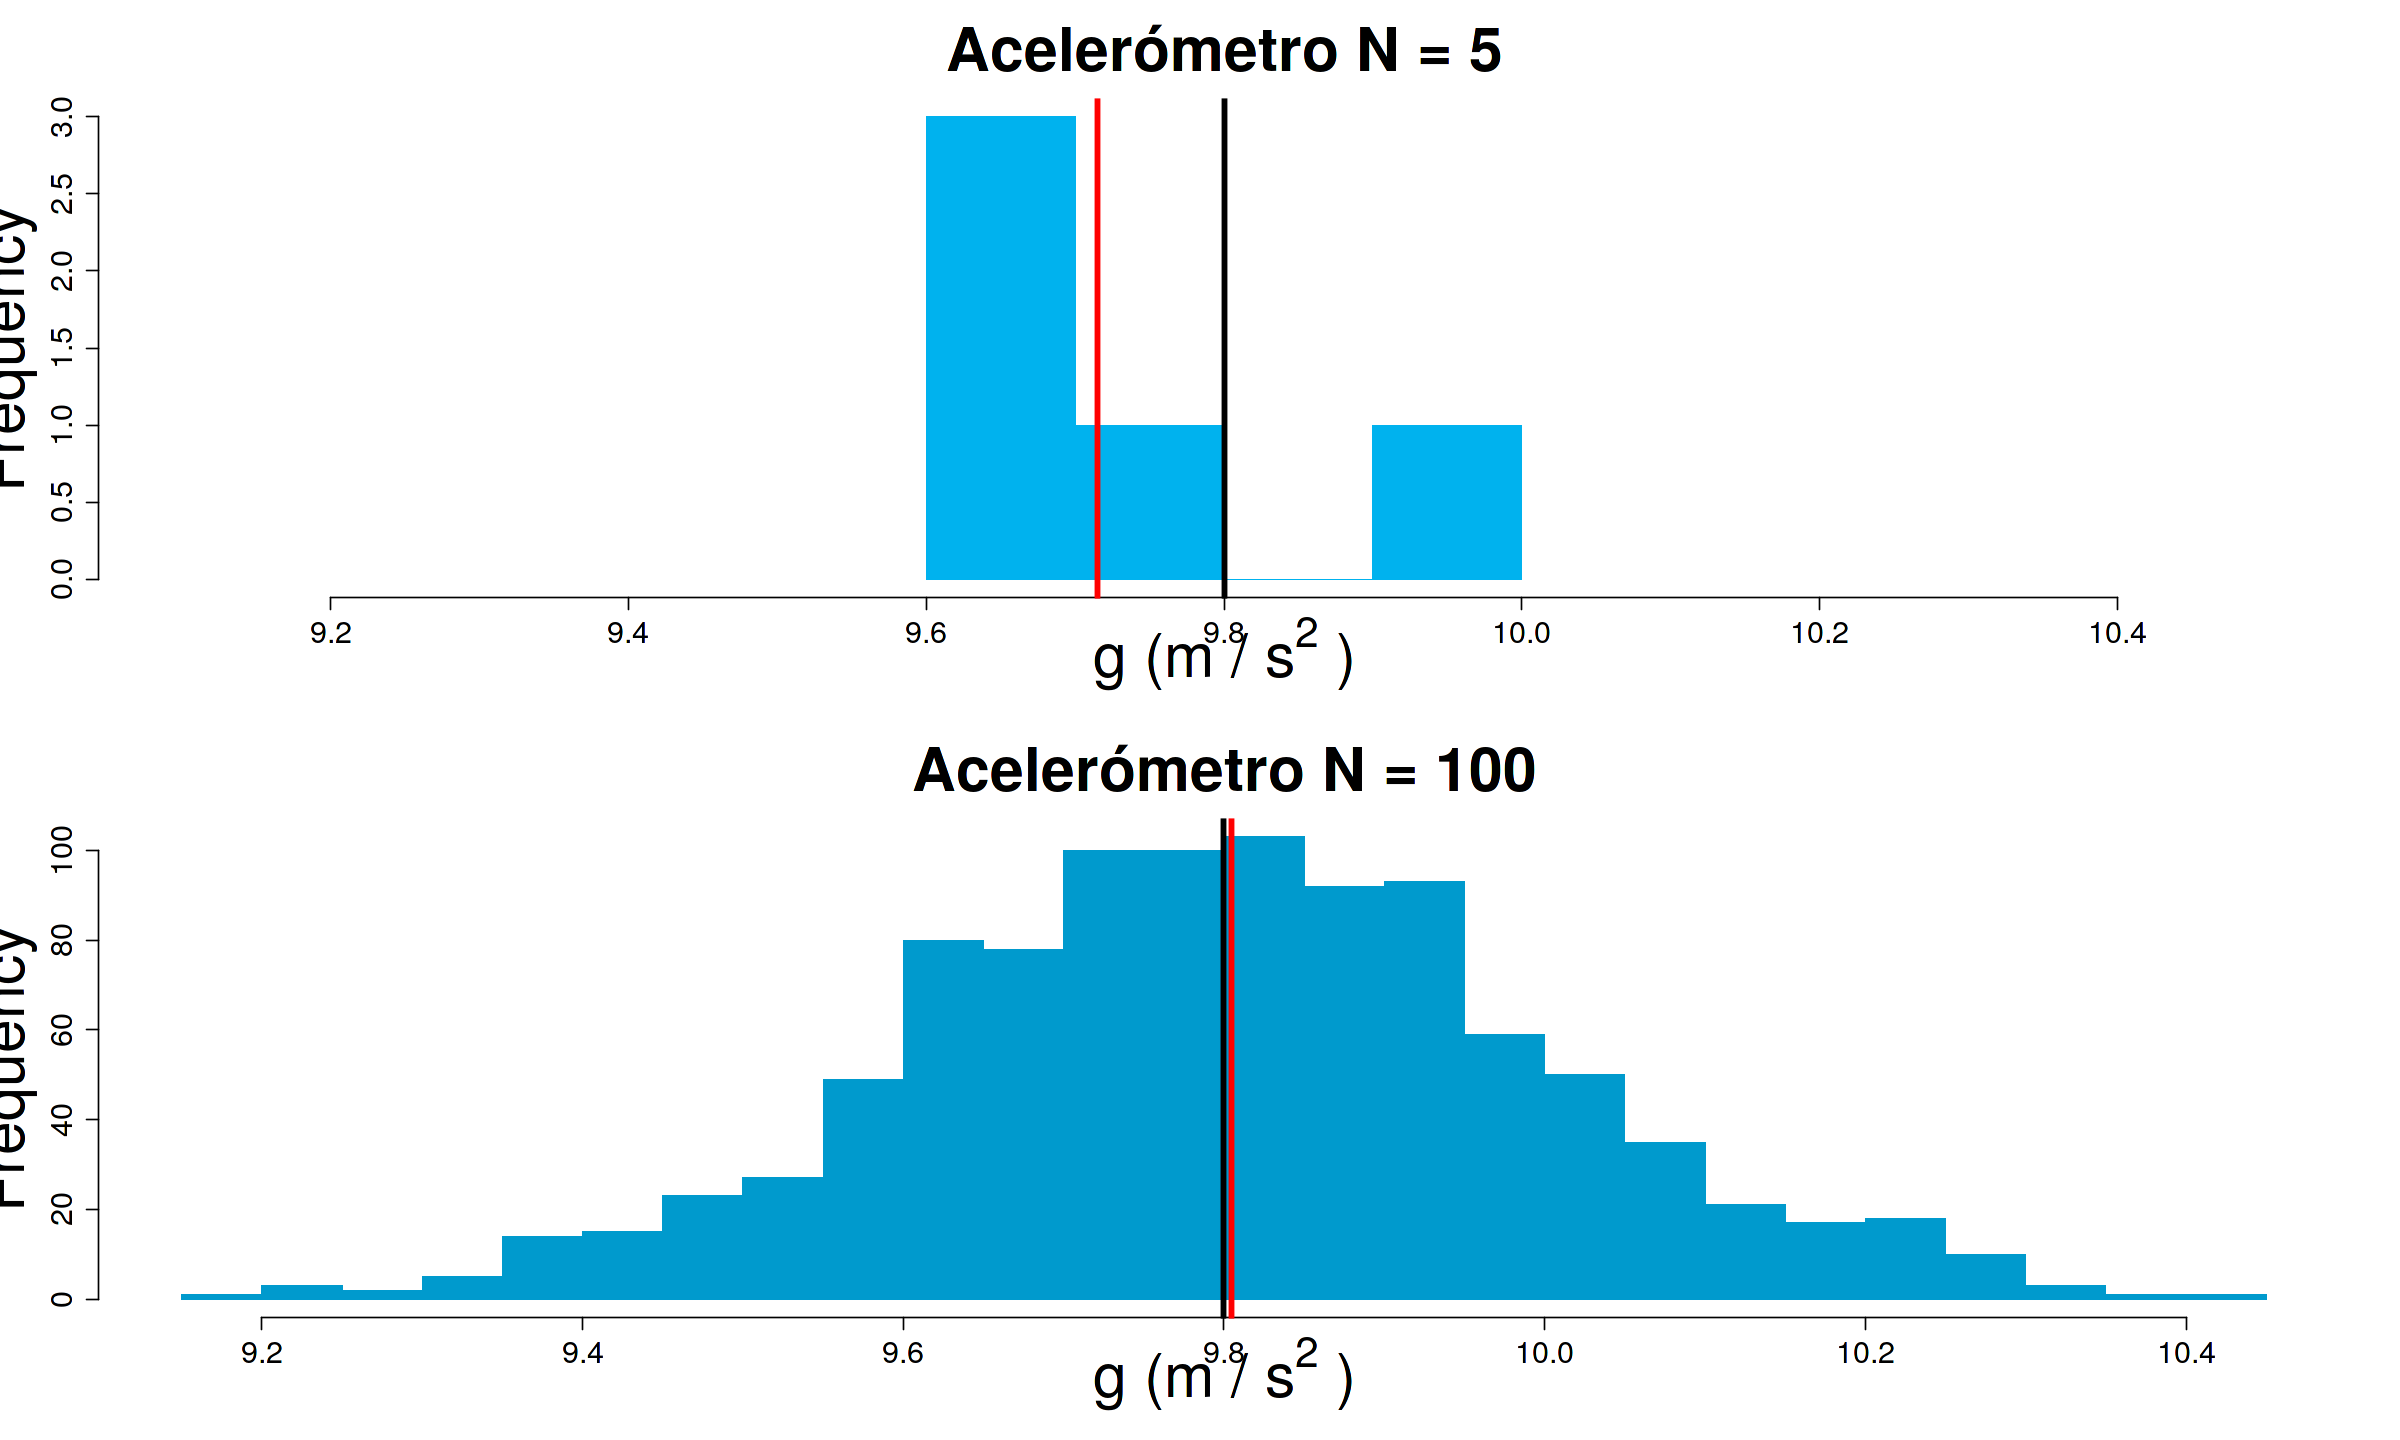

In [105]:
par(mfrow=c(2,1));fig(20,12);

hist(a5, breaks = nclass.FD(a5), border = NA ,main = "Acelerómetro N = 5", xlab = expression(paste("g (m / ", s^2, " )")), col = "Deepskyblue2", cex.axis = 1.5,cex.lab = 3, cex.main = 3, xlim = c(9.1,10.5) ); abline(v = c(9.8, mean(a5)), col = c("Black", "Red"), lwd = 3.5)
hist(a100, breaks = nclass.FD(a100), border = NA,main = "Acelerómetro N = 100", xlab = expression(paste("g (m / ", s^2, " )")), col = "Deepskyblue3", cex.axis = 1.5,cex.lab = 3, cex.main = 3, c(9.1,10.5) ); abline(v = c(9.8, mean(a100)), col = c("Black", "Red"), lwd = 3.5)

Como vemos:

* La media muestral tiene una dependencia con el tamaño de la muestra, $N$ menor siempre es ***pior***.


* La media muestral es una variable aleatoria, es decir, si medimos ***otras*** 5 o cien veces, no nos va a dar lo mismo.


* Esto influye de alguna manera en la determinación de $\mu$, que es la media de la distribución que modelamos.


* La cuestión es *cuantificar* el conocimiento sobre $\mu$...aunque, de antemano, conocimiento con precisión infinita no existe (o requiere infinitas medidas).



### Alguna digresión sobre la media muestral $\bar{x}$

* Los valores no están ordenados, es decir, no se aprecia alguna relación entre $n_i$ y $n_{i+1}$.Lo que sí se puede observar es cómo los puntos tienden a reunirse en una ***línea*** al centro.


* Vemos que la media no esta muy lejos del valor central (esta en la misma clase) pero podría estimarlo mejor.


* "Es erróneo elegir una medida por encima de las demás dado que todas se realizaron bajo condiciones idénticas. Lo ideal sería calcular la media muestral y usarla como nuestra mejor aproximación al modelo, o, mejor dicho, nuestra medida más “fiable”."

#### Media: Definición:

La media de una distribución cualquiera (el primer momento de una distribución) se define como:

$$
\mu = \int_{-\infty}^\infty x f(x) dx \\
\mu = \sum x p(x)
$$


#### Media muestral: una cuenta naïve (naíf según la RAE)

$$
\overline{x} = \sum_{i = 1}^n \frac{x_i}{n} = \frac{x_1 + x_2 + ... + x_n}{n}
$$

Pensemos en que algunas $x_i$ se "repiten" un número $n_i$ de veces: 
$$
\overline{x} = \frac{x_1 + x_2 + ... + x_n}{n} = \sum_{n = 1}^{N} \frac{x_i n_i}{N} =\sum_{n = 1}^{N} x_i \frac{n_i}{N}
$$

Si hacemos que $N \rightarrow \infty$....
$$
\overline{x} ({N \rightarrow \infty}) \; = \;\; \sum_{n = 1}^{N \rightarrow  \infty} \; \; x_i \;\; \overbrace{\frac{n_i}{N}}^{p(x)} \; \; =  \;\mu
$$



### Teorema del Límite Central

* El TLC da vueltas sobre la distribución de probabilidad de la media muestral, considerada como una ***variable aleatoria***.


* Tiene un criterio general.

**Teorema (una de las versiones sin demostración)**
$$X_1 -> \text{medir...} -> x_1 \text{(un valor)} $$
Sean $X_1, X_2, X_3,.., X_N$, N variables aleatorias ***independientes e idénticamente distribuídas*** (IID), con distribuciones de probabilidad ***inespecificadas***, con media $\mu$ y varianza $\sigma^2$.

Entonces la media de la muestra $$\bar{X} =  \sum_{i = 1}^{N} X_i / N$$

tiene una distribución con media $\mu$ y varianza $\sigma^2/N$, que se aproxima a una distribución normal a medida que $N\rightarrow \infty$

## Lo qué?  Un intento de explicar:

Supongamos que tenemos $10^6$ medidas de $g$ con un aparato raro, que no es el acelerómetro.

Suponemos una media no sesgada $\mu = 9.8 m/s^2$, con una desviación estándar $\sigma$ mayor que cero y no infinita.


[1] 0.9978001

[1] 0.002097327

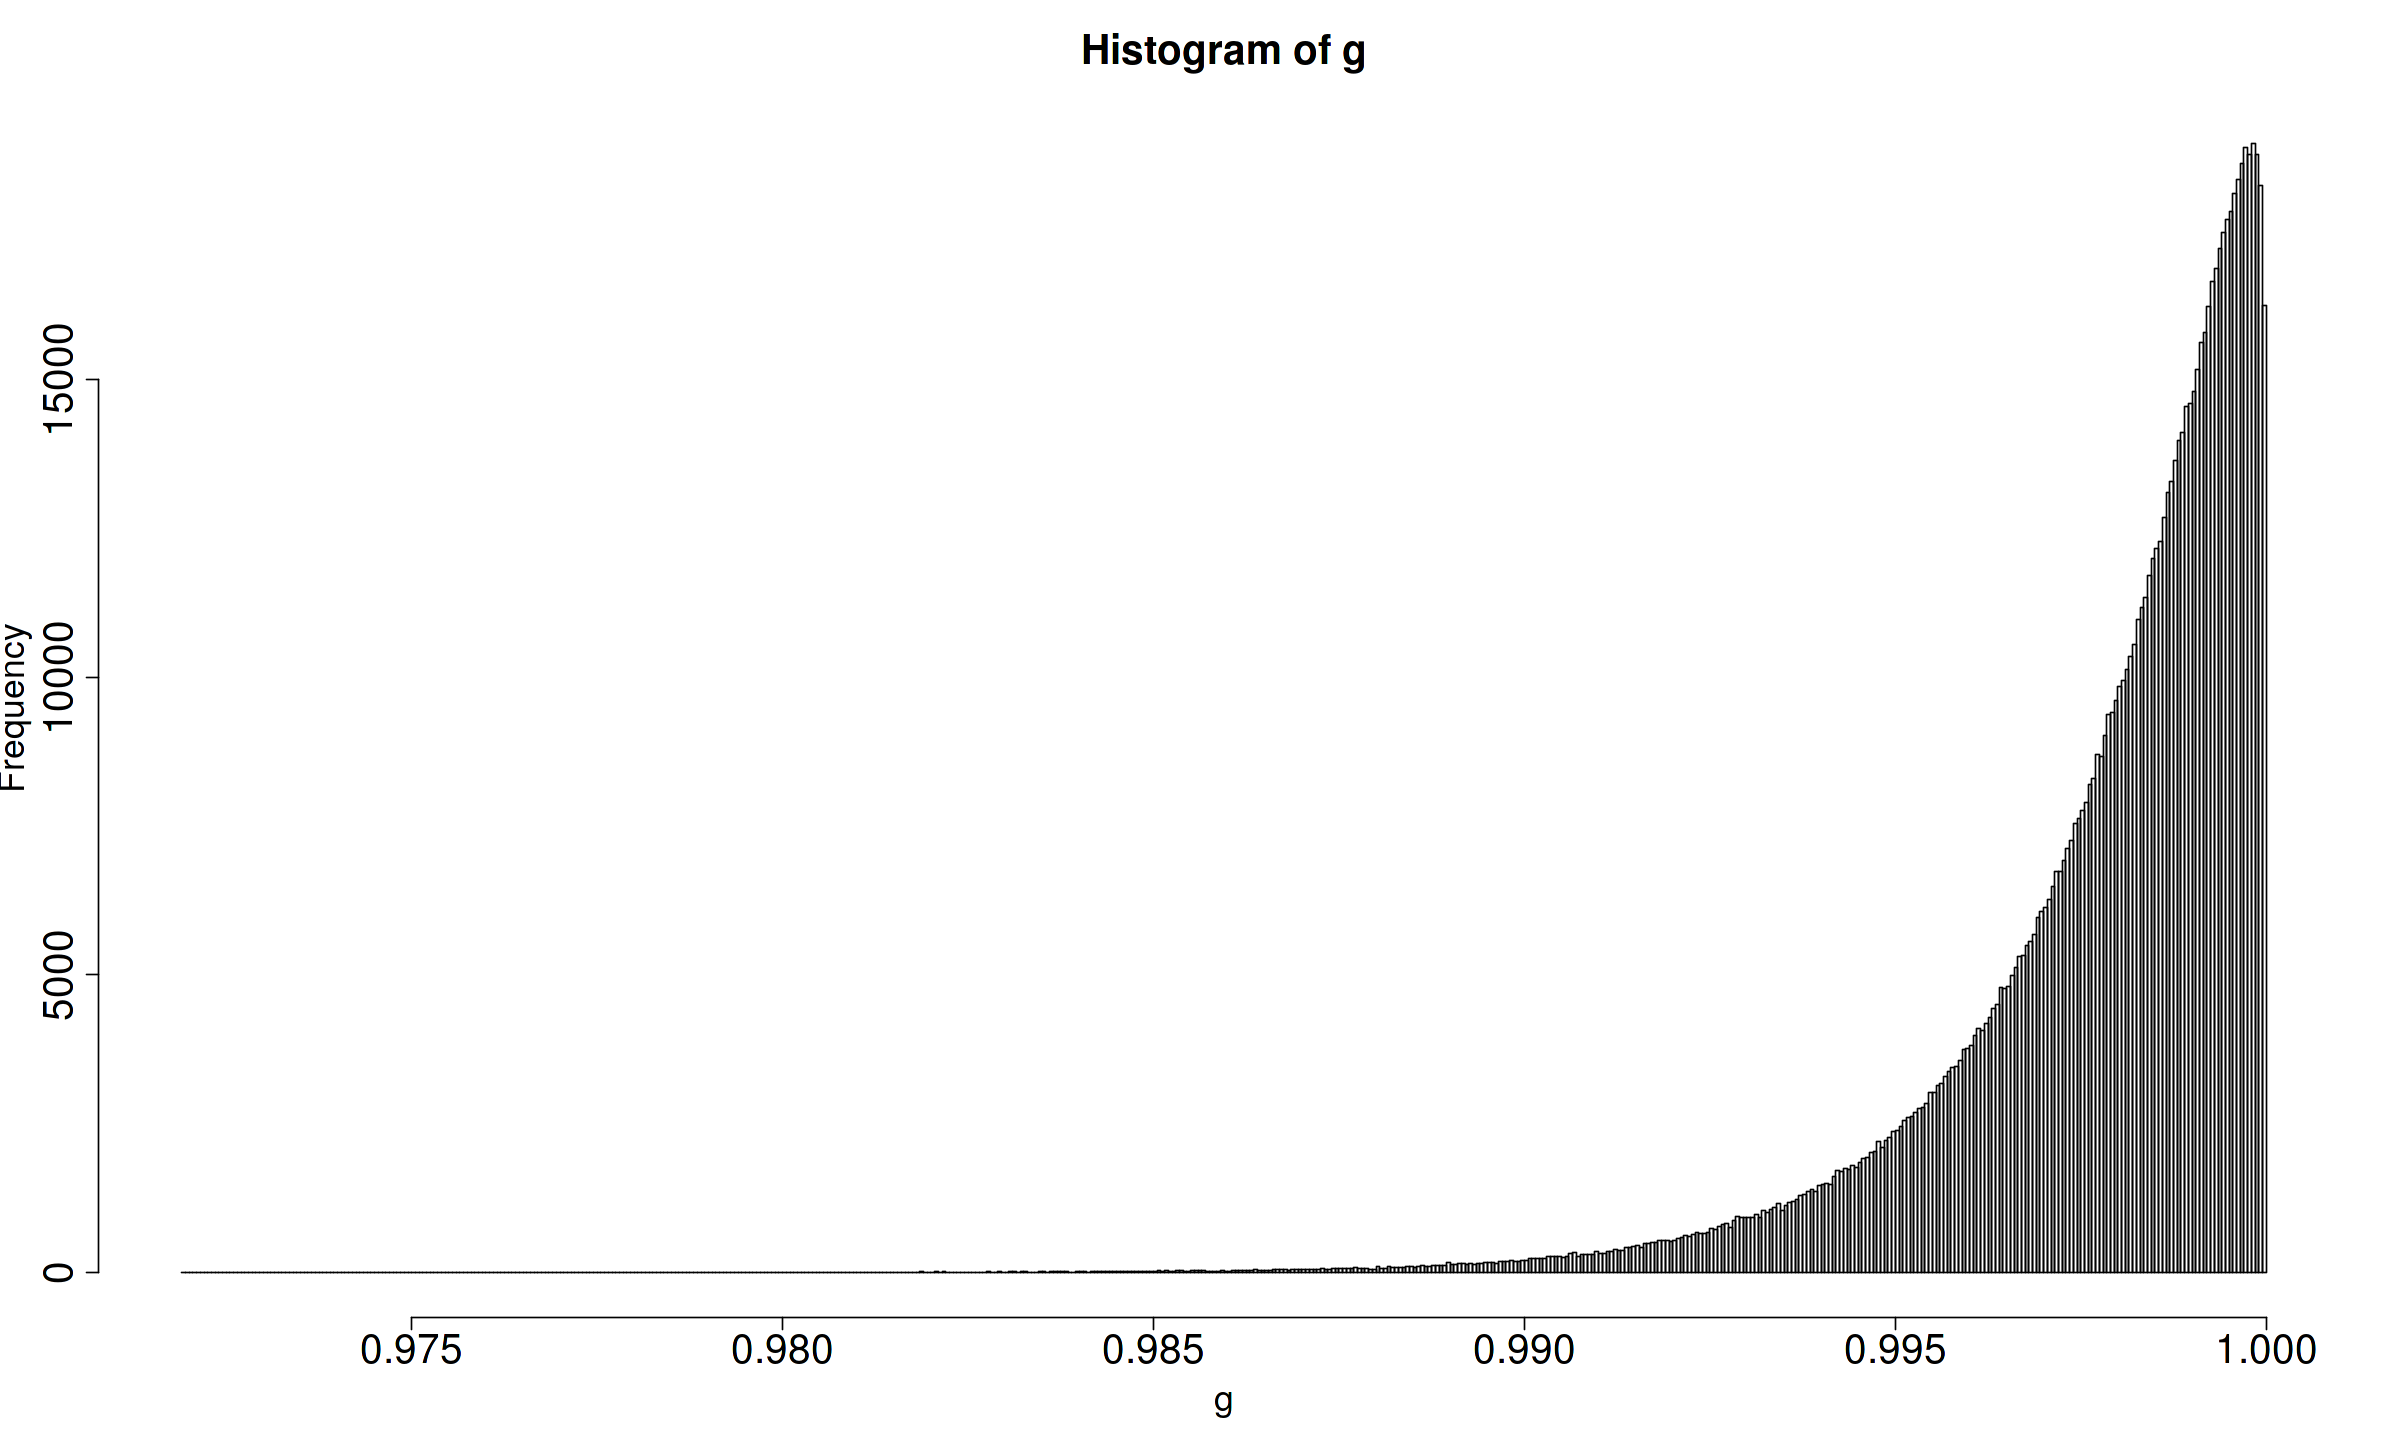

In [115]:
#g <- rnorm(mean = 9.8, sd = 1, n = 10^6)
#g <- runif(min = 9.5, max = 10.1, n = 10^6);
#g <- rpois(lambda = 9.8, n = 10^6);
#g <- rexp(rate  = 1/9.8, n = 10^6);
g <- rbeta(shape1 = 0.1, shape2 = 1.1, n = 10^6, ncp = 1000);

hist(g, breaks = nclass.FD(g), cex.main = 2, cex.lab = 1.75, cex.axis = 2);
mean(g); sd(g)

Hacemos 10000 medias muestrales de $n = 100$:

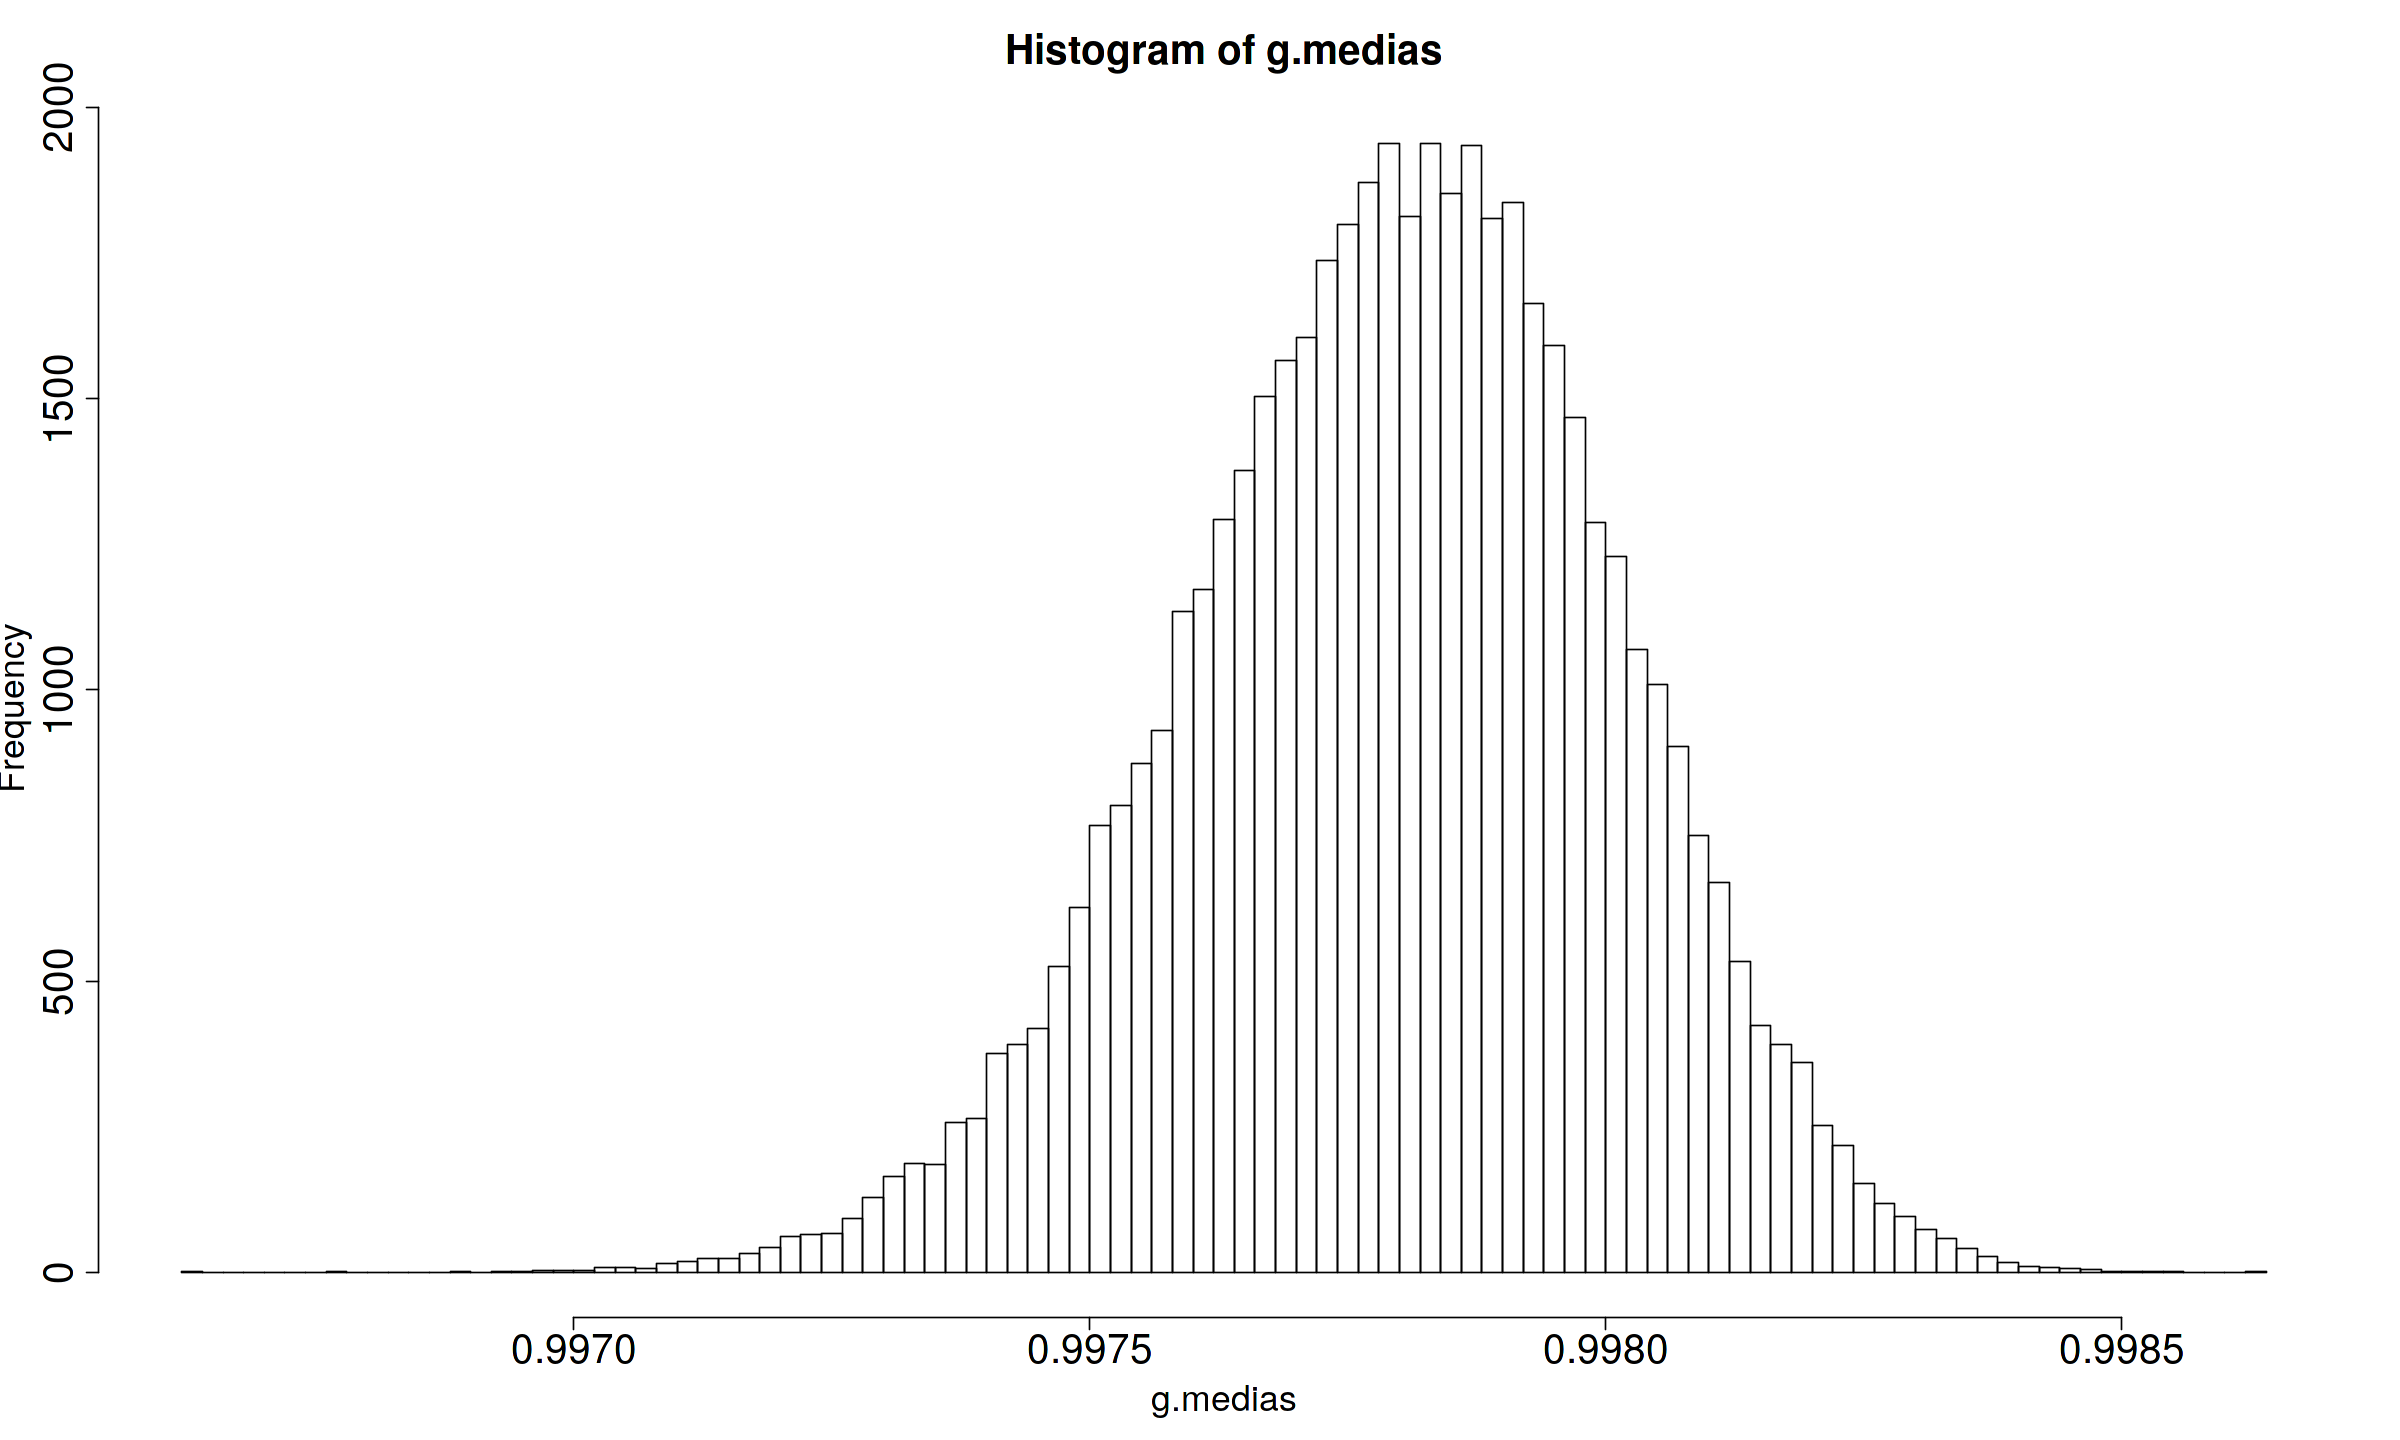

In [116]:
m <- 5*10^4; n = 100; 
g.medias <- vector(mode = "numeric", length = m)
for(i in 1:m){
g.medias[i] <- mean(sample(g, size = n, replace = T))    
}

hist(g.medias, breaks = nclass.FD(g.medias),cex.main = 2, cex.lab = 1.75, cex.axis = 2)

* La media muestral se distribuye como una normal:

Esa normal tiene:

* La misma media $\mu$ que la distribución original.


* Una desviación estándar más chica: $$\sigma(\; \overline{g} \;) = \frac{\sigma}{\sqrt{n}}$$ 